In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import cv2

image = cv2.imread("D:/open cv/Feature Detection and Description/babarazam.jpeg")

gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

cv2.imshow("Original Image", image)
cv2.imshow("Gray Image", gray_image)

cv2.waitKey(0)
cv2.destroyAllWindows()

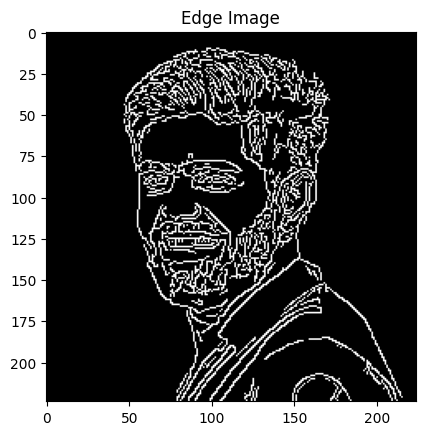

In [3]:
edges = cv2.Canny(gray_image, 100, 200)
plt.imshow(edges, cmap='gray')
plt.title('Edge Image')
plt.show()

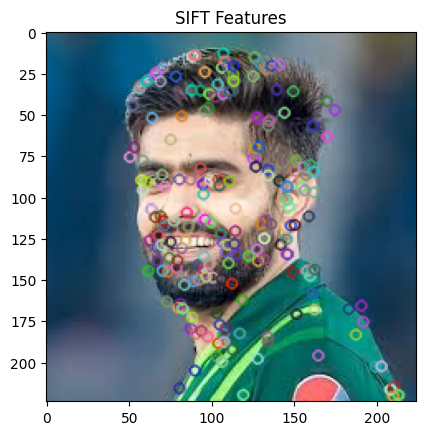

In [4]:
sift = cv2.SIFT_create()
keypoints, descriptors = sift.detectAndCompute(gray_image, None)
image_with_sift = cv2.drawKeypoints(image, keypoints, None)
plt.imshow(cv2.cvtColor(image_with_sift, cv2.COLOR_BGR2RGB))
plt.title('SIFT Features')
plt.show()

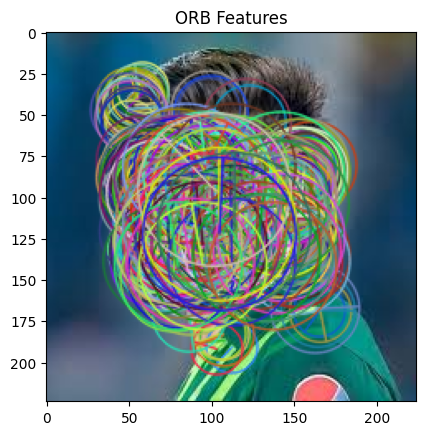

In [5]:
orb = cv2.ORB_create()
keypoints, descriptors = orb.detectAndCompute(gray_image, None)
image_with_orb = cv2.drawKeypoints(image, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.imshow(cv2.cvtColor(image_with_orb, cv2.COLOR_BGR2RGB))
plt.title('ORB Features')
plt.show()

In [6]:
import numpy as np
import cv2
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

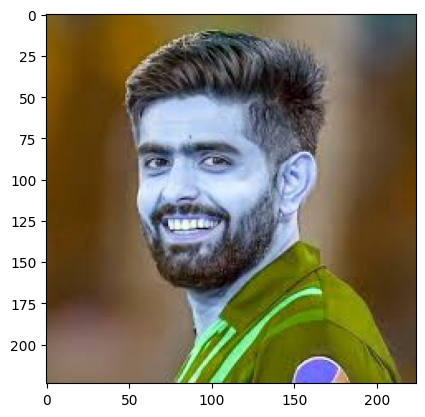

In [7]:
img = cv2.imread("D:/open cv/Feature Detection and Description/babarazam.jpeg")
plt.imshow(img)

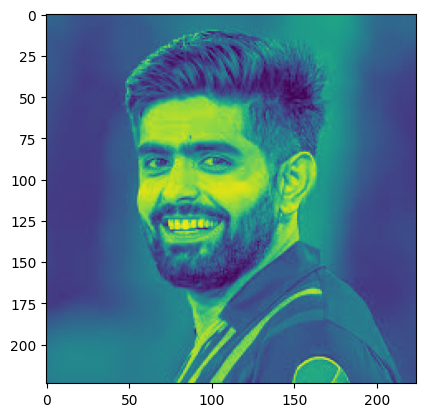

In [8]:
#Converting the image to gray
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray.shape
plt.imshow(gray)

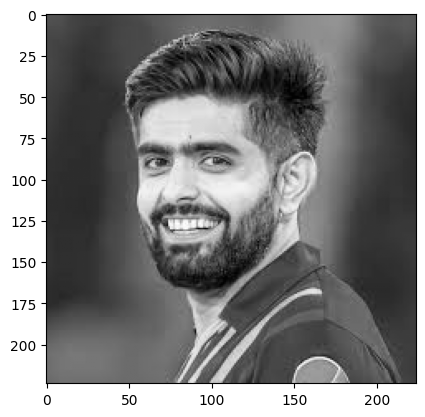

In [9]:
plt.imshow(gray, cmap='gray')

[[ 31  48 105 105]]


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

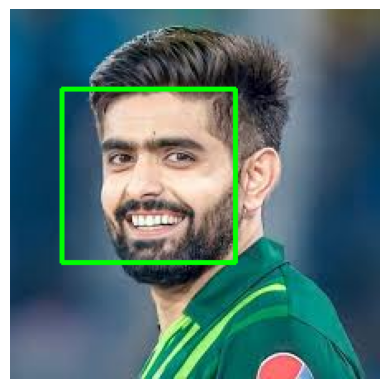

In [10]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("D:/open cv/Feature Detection and Description/babarazam.jpeg")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

faces = face_cascade.detectMultiScale(gray, 1.3, 5)

print(faces)

for (x,y,w,h) in faces:
    cv2.rectangle(img,(x,y),(x+w,y+h),(0,255,0),2)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")

In [11]:
(x,y,w,h) = faces[0]
x,y,w,h

(np.int32(31), np.int32(48), np.int32(105), np.int32(105))

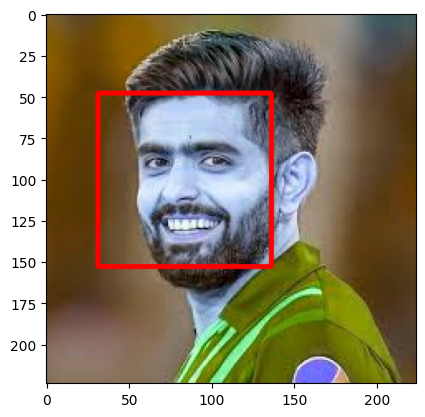

In [12]:
face_img = cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
plt.imshow(face_img)

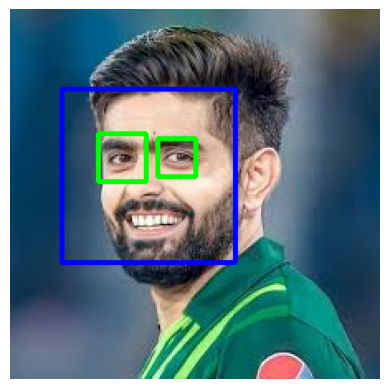

In [13]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("D:/open cv/Feature Detection and Description/babarazam.jpeg")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_eye.xml")

faces = face_cascade.detectMultiScale(gray, 1.3, 5)

for (x,y,w,h) in faces:

    cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)

    roi_gray = gray[y:y+h, x:x+w]
    roi_color = img[y:y+h, x:x+w]

    eyes = eye_cascade.detectMultiScale(roi_gray)

    for (ex,ey,ew,eh) in eyes:
        cv2.rectangle(roi_color,(ex,ey),(ex+ew,ey+eh),(0,255,0),2)

plt.figure()
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

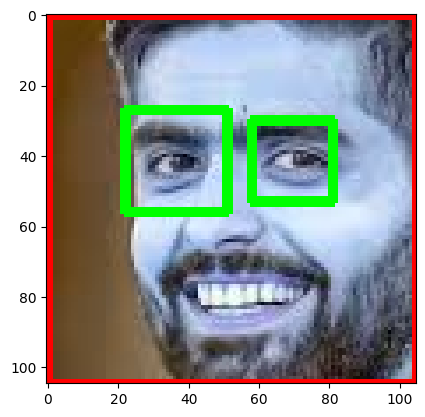

In [14]:
#Plotting the cropped Image
%matplotlib inline
plt.imshow(roi_color, cmap='gray')
plt.show()

In [15]:
cropped_img = np.array(roi_color)
cropped_img.shape

(105, 105, 3)

In [17]:
import numpy as np
import pywt
import cv2    

def w2d(img, mode='haar', level=1):
    imArray = img
    #Datatype conversions
    #convert to grayscale
    imArray = cv2.cvtColor( imArray,cv2.COLOR_RGB2GRAY )
    #convert to float
    imArray =  np.float32(imArray)   
    imArray /= 255;
    # compute coefficients 
    coeffs=pywt.wavedec2(imArray, mode, level=level)

    #Process Coefficients
    coeffs_H=list(coeffs)  
    coeffs_H[0] *= 0;  

    # reconstruction
    imArray_H=pywt.waverec2(coeffs_H, mode);
    imArray_H *= 255;
    imArray_H =  np.uint8(imArray_H)

    return imArray_H

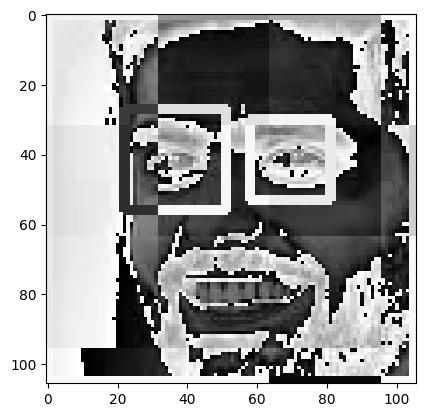

In [18]:
im_har = w2d(cropped_img,'db1',5)
plt.imshow(im_har, cmap='gray')

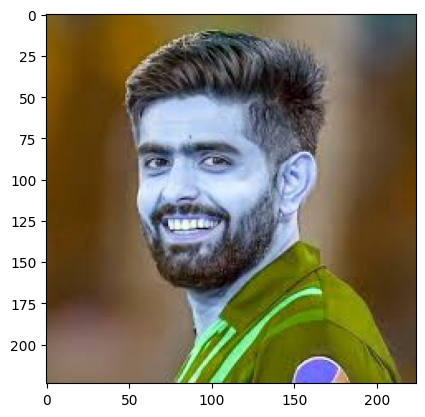

In [19]:
def get_cropped_image_if_2_eyes(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    for (x,y,w,h) in faces:
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = img[y:y+h, x:x+w]
        eyes = eye_cascade.detectMultiScale(roi_gray)
        if len(eyes) >= 2:
            return roi_color
          
original_image = cv2.imread("D:/open cv/Feature Detection and Description/babarazam.jpeg")
plt.imshow(original_image)

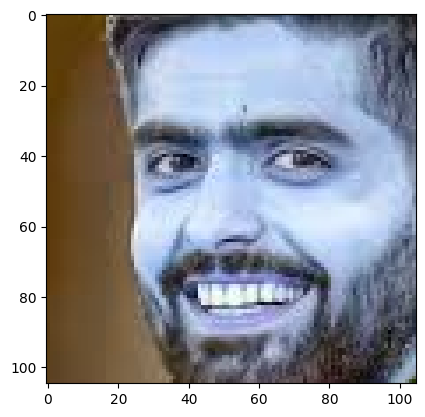

In [20]:
cropped_image = get_cropped_image_if_2_eyes("D:/open cv/Feature Detection and Description/babarazam.jpeg")
plt.imshow(cropped_image)

In [32]:
import os

path_to_data = "D:/open cv/images/"
path_to_cr_data = "D:/open cv/images/cropped/"

# Ensure cropped folder exists
os.makedirs(path_to_cr_data, exist_ok=True)

# List all subdirectories in path_to_data
img_dirs = [entry.path for entry in os.scandir(path_to_data) if entry.is_dir()]
print(img_dirs)

['D:/open cv/images/cropped']


In [23]:
import shutil
if os.path.exists(path_to_cr_data):
     shutil.rmtree(path_to_cr_data)
os.mkdir(path_to_cr_data)

In [24]:
cropped_image_dirs = []
celebrity_file_names_dict = {}

for img_dir in img_dirs:
    count = 1
    celebrity_name = img_dir.split('/')[-1]
    print(celebrity_name)
    
    celebrity_file_names_dict[celebrity_name] = []
    
    for entry in os.scandir(img_dir):
        roi_color = get_cropped_image_if_2_eyes(entry.path)
        if roi_color is not None:
            cropped_folder = path_to_cr_data + celebrity_name
            if not os.path.exists(cropped_folder):
                os.makedirs(cropped_folder)
                cropped_image_dirs.append(cropped_folder)
                print("Generating cropped images in folder: ",cropped_folder)
                
            cropped_file_name = celebrity_name + str(count) + ".png"
            cropped_file_path = cropped_folder + "/" + cropped_file_name 
            
            cv2.imwrite(cropped_file_path, roi_color)
            celebrity_file_names_dict[celebrity_name].append(cropped_file_path)
            count += 1

cropped


In [25]:
celebrity_file_names_dict = {}
for img_dir in cropped_image_dirs:
    celebrity_name = img_dir.split('/')[-1]
    file_list = []
    for entry in os.scandir(img_dir):
        file_list.append(entry.path)
    celebrity_file_names_dict[celebrity_name] = file_list
celebrity_file_names_dict

{}

In [26]:
class_dict = {}
count = 0
for celebrity_name in celebrity_file_names_dict.keys():
    class_dict[celebrity_name] = count
    count = count + 1
class_dict

{}

In [27]:
X, y = [], []
for celebrity_name, training_files in celebrity_file_names_dict.items():
    for training_image in training_files:
        img = cv2.imread(training_image)
        if img is None:
            continue
        scalled_raw_img = cv2.resize(img, (32, 32))
        img_har = w2d(img,'db1',5)
        scalled_img_har = cv2.resize(img_har, (32, 32))
        combined_img = np.vstack((scalled_raw_img.reshape(32*32*3,1),scalled_img_har.reshape(32*32,1)))
        X.append(combined_img)
        y.append(class_dict[celebrity_name])

In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

pipe = Pipeline([('scaler', StandardScaler()), ('svc', SVC(kernel = 'rbf', C = 10))])
pipe.fit(X_train, y_train)
pipe.score(X_test, y_test)

In [ ]:
import os
path_to_data = "D:/open cv/Feature Detection and Description/babarazam.jpeg"
img_dirs = [entry.path for entry in os.scandir(path_to_data) if entry.is_dir()]
print(img_dirs)
import cv2
import numpy as np

X = []
y = []

label = 0
for folder in img_dirs:
    for file in os.listdir(folder):
        img_path = os.path.join(folder, file)
        img = cv2.imread(img_path)
        if img is None:
            continue
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        resized = cv2.resize(gray, (50,50))   # resize for consistency
        X.append(resized.flatten())           # flatten to 1D
        y.append(label)
    label += 1

X = np.array(X)
y = np.array(y)
print("X shape:", X.shape, "y shape:", y.shape)
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf', C=10))
])

pipe.fit(X_train, y_train)
print("Test Accuracy:", pipe.score(X_test, y_test))

In [ ]:
print(classification_report(y_test, pipe.predict(X_test)))